<a href="https://colab.research.google.com/github/amirf95/Image-processing/blob/hmw1/Lab03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3 – Filtering + Edge Detection


## Load Image

TypeError: Image data of dtype object cannot be converted to float

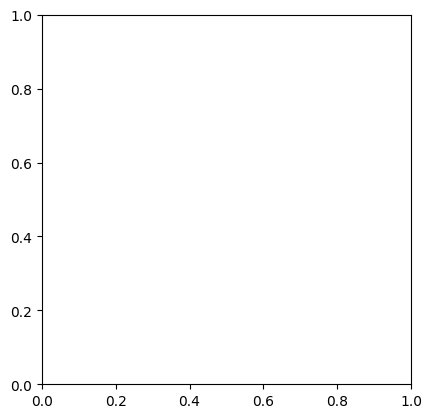

In [1]:
import cv2, matplotlib.pyplot as plt
img=cv2.imread('sample.png',0)
plt.imshow(img,cmap='gray')

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def show(title, img):
    plt.figure(figsize=(5,5))
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

In [8]:
from google.colab import files
files.upload()


Saving coins.png to coins.png


{'coins.png': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02\xee\x00\x00\x02i\x08\x03\x00\x00\x00\xc5vG\x98\x00\x00\x03\x00PLTE\xff\xff\xff\xf3\xf4\xf4\xf1\xf1\xf1\xeb\xed\xec\xf0\xf2\xf1\xec\xee\xed\xf1\xf3\xf2\xee\xf0\xef\xf0\xf1\xf0\xed\xef\xee\xf2\xf2\xf2\xf3\xf3\xf3\xea\xec\xec\xee\xee\xef\xed\xed\xeb\xeb\xeb\xea\xe9\xea\xea\xe7\xe8\xe5\xe9\xec\xea\xef\xef\xec\xe9\xe9\xe7\xef\xef\xefiec\xe5\xe5\xe3qkhkgctnk\xea\xeb\xe8mie\xed\xed\xeeqmkhcbnji\xf6\xf6\xf5\xe7\xe8\xe8ea_\x88Y1ohf\xdf\xdf\xdd\xe3\xe3\xe3\x8cY0\xea\xeb\xe7\xe6\xe6\xe4\xef\xf0\xedldb\xf1\xf2\xeehc_\xe7\xea\xe8\xd7\xd6\xd4lff\xed\xf1\xef\xdb\xdb\xd9\x84W4\x86V/ofc\xd4\xd4\xd2\xe5\xe7\xe6\xe1\xe2\xe0xpm\xd9\xd9\xd7\x8d\\4tki\xf9\xfa\xf6\xe0\xe1\xdf\xf4\xf4\xf2b^^tpnrif\xf1\xf0\xee\xed\xef\xec\xcd\xcb\xc9\xc9\xc7\xc6\x7fqk\xf6\xf6\xf2\x89V-{M9wrq\xf8\xf8\xf3\x89[6iff\x84uo\xe3\xe4\xe1\xde\xde\xdc\x82T1\xdc\xdd\xdb|ni\xf2\xf3\xf0\xec\xf0\xeedbc{tqlii\x87X6\xcf\xce\xcc\x81sn\xc6\xc4\xc2{lf\x84S+\x86xrb[X\xee\xf2\xf0\x8dX

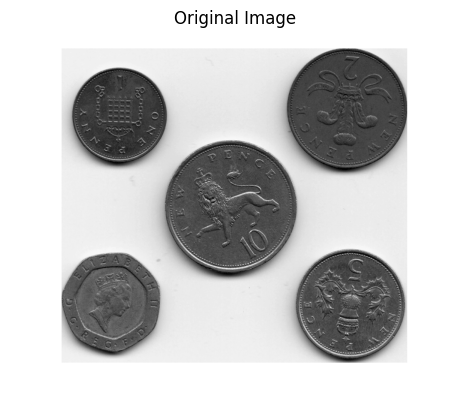

In [10]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("coins.png", 0)

if img is None:
    raise ValueError("coins.png failed to load")

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()


## Experiment: Gaussian Blur

This experiment applies a Gaussian blur filter to the original image to demonstrate its smoothing effect.


---



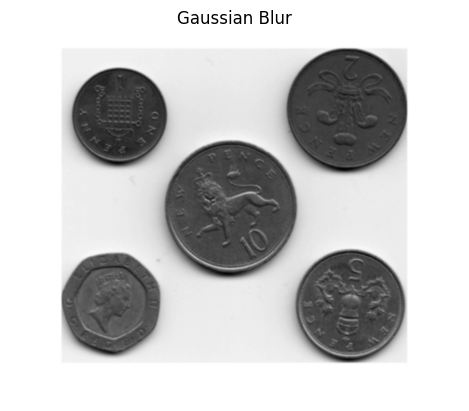

In [11]:
blur = cv2.GaussianBlur(img, (5,5), 0)

plt.imshow(blur, cmap='gray')
plt.title("Gaussian Blur")
plt.axis('off')
plt.show()


## Experiment: Comparison of Various Smoothing Filters

This section applies and compares several common smoothing filters: Mean, Gaussian, Median, and Bilateral filters, to observe their distinct effects on the image.


---



### Analysis of Gaussian Blur

The Gaussian blur has successfully smoothed the image, reducing noise and fine details. This is evident by the image appearing less sharp and some of the smaller features being blended out.


---



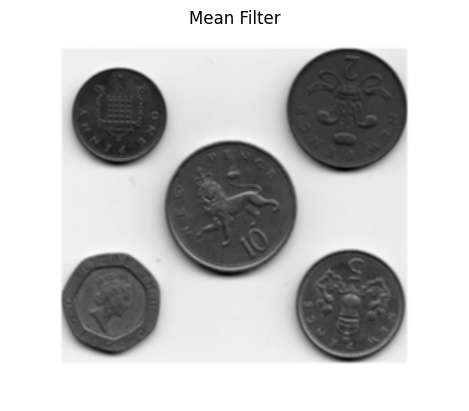

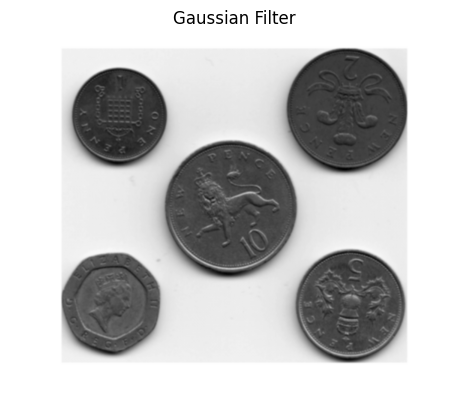

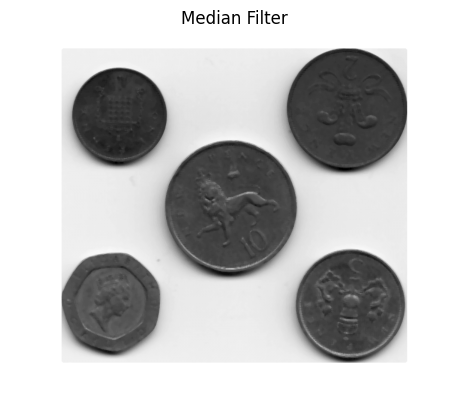

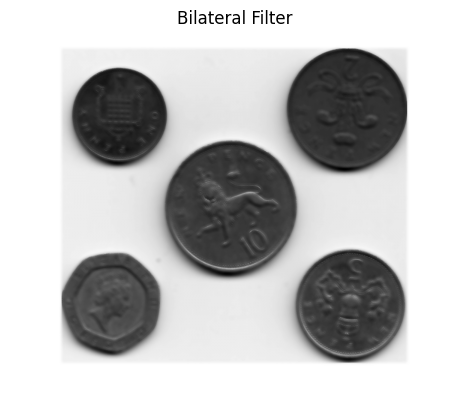

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Mean Filter
mean_filtered = cv2.blur(img, (5,5))
plt.imshow(mean_filtered, cmap='gray')
plt.title("Mean Filter")
plt.axis('off')
plt.show()

# Gaussian Filter
gauss = cv2.GaussianBlur(img, (5,5), 0)
plt.imshow(gauss, cmap='gray')
plt.title("Gaussian Filter")
plt.axis('off')
plt.show()

# Median Filter
median = cv2.medianBlur(img, 5)
plt.imshow(median, cmap='gray')
plt.title("Median Filter")
plt.axis('off')
plt.show()

# Bilateral Filter
bilateral = cv2.bilateralFilter(img, 9, 75, 75)
plt.imshow(bilateral, cmap='gray')
plt.title("Bilateral Filter")
plt.axis('off')
plt.show()


## Experiment: Sharpening and Laplacian Filter

This experiment demonstrates image sharpening using Laplacian and Unsharp Masking techniques, which are often used to enhance edges and details.


---



### Analysis of Smoothing Filters

- **Mean Filter:** Provides a general blurring effect, averaging pixel values in a neighborhood. It's simple but can blur edges.
- **Gaussian Filter:** Offers a smoother blur than the mean filter, using a weighted average based on a Gaussian distribution, effectively reducing noise while preserving edges better than the mean filter.
- **Median Filter:** Excels at removing salt-and-pepper noise without blurring edges as much as linear filters. It replaces each pixel's value with the median of its neighbors.
- **Bilateral Filter:** A non-linear filter that smooths images while preserving strong edges. It considers both spatial proximity and intensity similarity, making it very effective for noise reduction without losing important structural information.

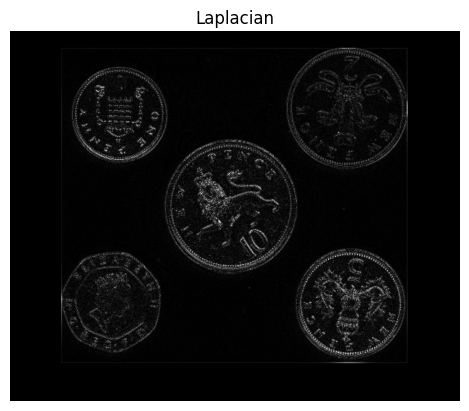

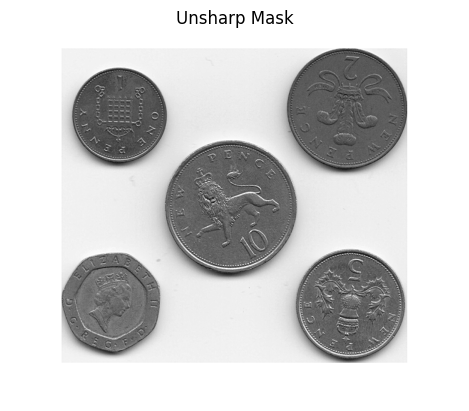

In [13]:
# Laplacian Filter
lap = cv2.Laplacian(img, cv2.CV_64F)
lap = cv2.convertScaleAbs(lap)
plt.imshow(lap, cmap='gray')
plt.title("Laplacian")
plt.axis('off')
plt.show()

# Unsharp Masking
blur = cv2.GaussianBlur(img, (7,7), 0)
unsharp = cv2.addWeighted(img, 1.5, blur, -0.5, 0)
plt.imshow(unsharp, cmap='gray')
plt.title("Unsharp Mask")
plt.axis('off')
plt.show()


## Experiment: Various Edge Detection Operators




This section explores different edge detection operators, including Roberts, Prewitt, Sobel, Laplacian of Gaussian (LoG), and Canny, to identify and compare their effectiveness in extracting edges from the image.


---



### Analysis of Sharpening and Laplacian Filter

- **Laplacian Filter:** Highlights regions of rapid intensity change, effectively detecting edges. The output image shows strong responses at boundaries, appearing as sharp white lines on a black background.
- **Unsharp Masking:** This technique sharpens the image by subtracting a blurred version of the image from the original. The result is an image with enhanced details and edges, appearing crisper than the original.


---



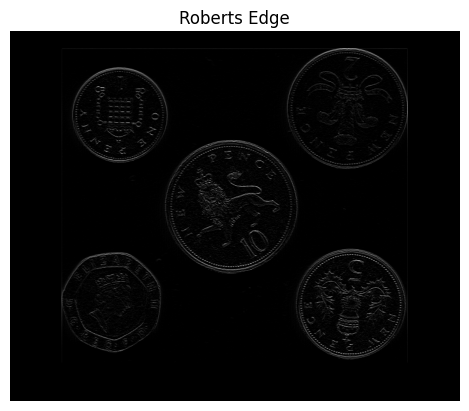

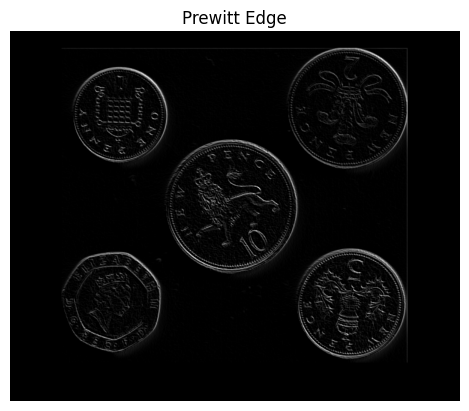

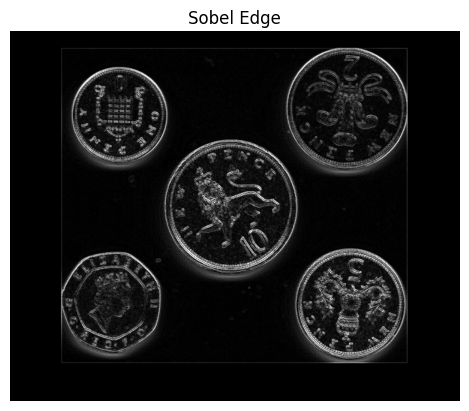

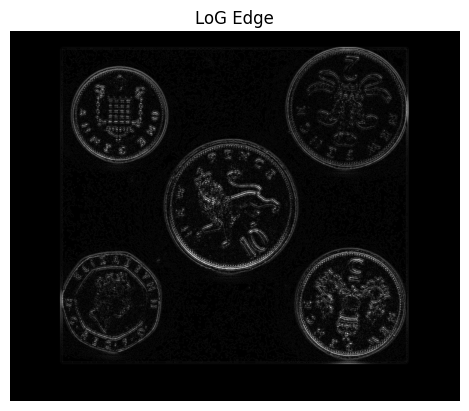

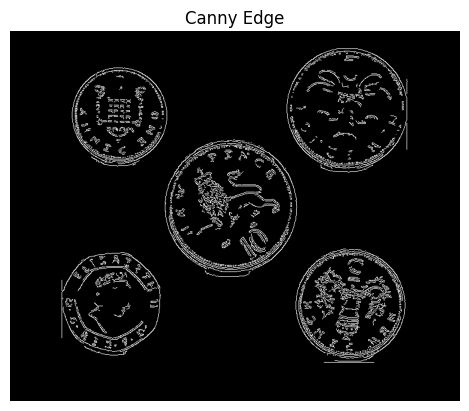

In [14]:
# Roberts Operator
kernel_x = np.array([[1, 0], [0, -1]])
kernel_y = np.array([[0, 1], [-1, 0]])

rob_x = cv2.filter2D(img, -1, kernel_x)
rob_y = cv2.filter2D(img, -1, kernel_y)
roberts = cv2.addWeighted(rob_x, 0.5, rob_y, 0.5, 0)
plt.imshow(roberts, cmap='gray')
plt.title("Roberts Edge")
plt.axis('off')
plt.show()

# Prewitt Operator
prewitt_x = np.array([[-1, 0, 1],
                      [-1, 0, 1],
                      [-1, 0, 1]])
prewitt_y = np.array([[1, 1, 1],
                      [0, 0, 0],
                      [-1, -1, -1]])

px = cv2.filter2D(img, -1, prewitt_x)
py = cv2.filter2D(img, -1, prewitt_y)
prewitt = cv2.addWeighted(px, 0.5, py, 0.5, 0)
plt.imshow(prewitt, cmap='gray')
plt.title("Prewitt Edge")
plt.axis('off')
plt.show()

# Sobel Operator
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

sobel = cv2.addWeighted(cv2.convertScaleAbs(sobel_x), 0.5,
                         cv2.convertScaleAbs(sobel_y), 0.5, 0)
plt.imshow(sobel, cmap='gray')
plt.title("Sobel Edge")
plt.axis('off')
plt.show()

# Laplacian of Gaussian
log = cv2.Laplacian(gauss, cv2.CV_64F)
log = cv2.convertScaleAbs(log)
plt.imshow(log, cmap='gray')
plt.title("LoG Edge")
plt.axis('off')
plt.show()

# Canny Edge Detector
canny = cv2.Canny(img, 100, 200)
plt.imshow(canny, cmap='gray')
plt.title("Canny Edge")
plt.axis('off')
plt.show()


### Analysis of Edge Detection Operators

- **Roberts Operator:** A simple, cross-gradient operator that detects edges by computing the sum of the squares of the differences between diagonally adjacent pixels. It's sensitive to noise.
- **Prewitt Operator:** Similar to Sobel, it approximates image gradients, but with simpler kernels. It's more robust to noise than Roberts but less accurate than Sobel.
- **Sobel Operator:** Calculates the image gradient more accurately than Prewitt, giving more weight to the center pixels of the kernel. It's widely used for its balance of noise suppression and edge detection.
- **Laplacian of Gaussian (LoG):** A two-step process that first smooths the image with a Gaussian filter to reduce noise, then applies a Laplacian operator to detect zero-crossings, which correspond to edges. It's effective but can produce thick edges.
- **Canny Edge Detector:** Considered an optimal edge detector due to its ability to find true weak edges, suppress false edges, and accurately localize edges. It uses a multi-stage algorithm including Gaussian smoothing, gradient calculation, non-maximum suppression, and hysteresis thresholding.


---



 Based on the analysis, the **Canny Edge Detector** produced the cleanest edges due to its multi-stage algorithm that effectively suppresses noise and accurately localizes edges.
 **The Roberts Operator** was most sensitive to noise, as it's a simple cross-gradient detector.
For real-world applications, the Canny Edge Detector would typically be preferred because of its optimal balance in finding true weak edges, suppressing false ones, and precise localization.

---

